In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,r2_score,root_mean_squared_error,mean_squared_error
from sklearn.model_selection import cross_val_score,GridSearchCV


In [95]:
df = pd.read_csv("ecom.csv")
print(df.head(5))

         Date  Order ID Customer ID Product ID Product Category  Product Name  \
0  2024-01-01  ORD00001    CUST1654     PROD23         Clothing       T-Shirt   
1  2024-01-02  ORD00002    CUST1114     PROD14           Sports  Coffee Maker   
2  2024-01-03  ORD00003    CUST1025     PROD43      Electronics      Lipstick   
3  2024-01-04  ORD00004    CUST1759     PROD18   Home & Kitchen       T-Shirt   
4  2024-01-05  ORD00005    CUST1281     PROD45           Sports    Smartphone   

   Quantity Sold  Unit Price  Discount (%)    Payment Method  \
0              5       28.75            15  Cash on Delivery   
1              1      302.32             5        Debit Card   
2              5      179.39            10        Debit Card   
3              3      395.35            15            PayPal   
4              1      223.83             0       Credit Card   

  Customer Location Order Status  Shipping Cost  Profit Margin  Customer Age  \
0       Los Angeles    Completed          11.12 

In [96]:
print("row,column",df.shape)
print("\ncolumns")
print(df.columns.tolist())
df["Date"]=pd.to_datetime(df["Date"])
print(df.info())

row,column (100, 20)

columns
['Date', 'Order ID', 'Customer ID', 'Product ID', 'Product Category', 'Product Name', 'Quantity Sold', 'Unit Price', 'Discount (%)', 'Payment Method', 'Customer Location', 'Order Status', 'Shipping Cost', 'Profit Margin', 'Customer Age', 'Customer Gender', 'Customer Segment', 'Review Rating', 'Total Sales', 'Discounted Price']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Date               100 non-null    datetime64[ns]
 1   Order ID           100 non-null    object        
 2   Customer ID        100 non-null    object        
 3   Product ID         100 non-null    object        
 4   Product Category   100 non-null    object        
 5   Product Name       100 non-null    object        
 6   Quantity Sold      100 non-null    int64         
 7   Unit Price         100 non-null    fl

In [97]:
print(df.isnull().sum())

print("\n",df.duplicated().sum())



Date                 0
Order ID             0
Customer ID          0
Product ID           0
Product Category     0
Product Name         0
Quantity Sold        0
Unit Price           0
Discount (%)         0
Payment Method       0
Customer Location    0
Order Status         0
Shipping Cost        0
Profit Margin        0
Customer Age         0
Customer Gender      0
Customer Segment     0
Review Rating        0
Total Sales          0
Discounted Price     0
dtype: int64

 0


STATISTICS

In [98]:
print(df.describe())
q1=df["Total Sales"].quantile(0.25)
q3=df["Total Sales"].quantile(0.75)
print(q1)
print(q3)
iqr=q3-q1
print(iqr)
lower_bound= q1 -(1.5*iqr)
upper_bound= q3 +(1.5*iqr)
print("lower_bound",lower_bound)
print("upper_bound",upper_bound)
condition=(df["Total Sales"]<lower_bound)|(df["Total Sales"]>upper_bound)

condition.sum()


                      Date  Quantity Sold  Unit Price  Discount (%)  \
count                  100      100.00000  100.000000     100.00000   
mean   2024-02-19 12:00:00        2.75000  283.797900       9.80000   
min    2024-01-01 00:00:00        1.00000   28.750000       0.00000   
25%    2024-01-25 18:00:00        2.00000  177.000000       5.00000   
50%    2024-02-19 12:00:00        3.00000  297.200000      10.00000   
75%    2024-03-15 06:00:00        4.00000  395.102500      15.00000   
max    2024-04-09 00:00:00        5.00000  492.280000      20.00000   
std                    NaN        1.34371  131.989975       6.77637   

       Shipping Cost  Profit Margin  Customer Age  Review Rating  Total Sales  \
count     100.000000     100.000000    100.000000     100.000000   100.000000   
mean       12.451100      15.587600     37.670000       2.990000   769.312800   
min         5.040000       5.160000     18.000000       1.000000    71.070000   
25%         8.565000      10.915000 

np.int64(1)

Date                2024-02-19 12:00:00
Quantity Sold                      2.75
Unit Price                     283.7979
Discount (%)                        9.8
Shipping Cost                   12.4511
Profit Margin                   15.5876
Customer Age                      37.67
Review Rating                      2.99
Total Sales                    769.3128
Discounted Price               692.1723
dtype: object


C:\Users\bahug\AppData\Local\Temp\ipykernel_14184\150951052.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


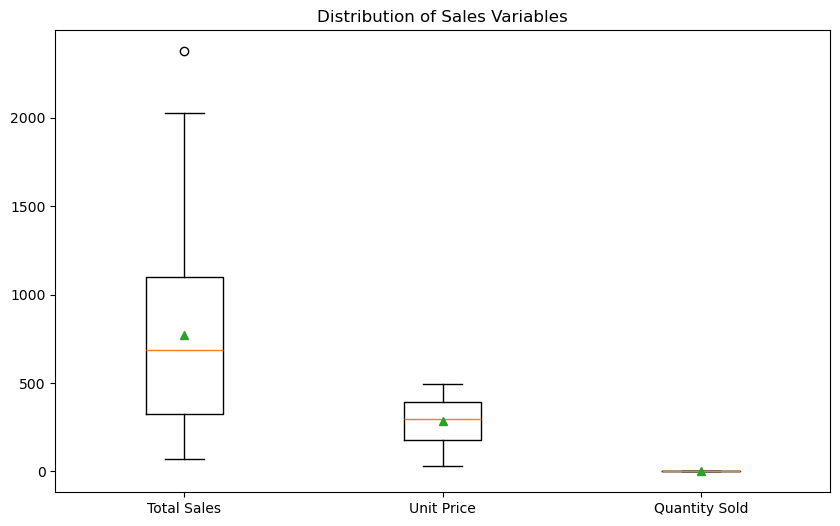

Discounted Price    1.000000
Total Sales         0.990433
Unit Price          0.665798
Quantity Sold       0.614993
Profit Margin      -0.020102
Review Rating      -0.045647
Shipping Cost      -0.066330
Customer Age       -0.094439
Name: Discounted Price, dtype: float64


In [99]:
print(df[["Date","Quantity Sold","Unit Price","Discount (%)","Shipping Cost","Profit Margin","Customer Age","Review Rating","Total Sales","Discounted Price"]].mean())
plt.figure(figsize=(10, 6))

plt.boxplot(
    [df["Total Sales"], df["Unit Price"], df["Quantity Sold"]],
    labels=["Total Sales", "Unit Price", "Quantity Sold"],
    showmeans=True
)

plt.title("Distribution of Sales Variables")
plt.show()
numerical_columns=df[[
    "Quantity Sold","Unit Price" , "Customer Age" ,"Review Rating" ,
    "Shipping Cost" ,"Profit Margin","Discounted Price","Total Sales"]]
correlation=numerical_columns.corr()["Discounted Price"]
print(correlation.sort_values(ascending=False))

C:\Users\bahug\AppData\Local\Temp\ipykernel_14184\2115824215.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  k=plt.boxplot([d,f],labels=["Clothing","Electronics"],showmeans=True)


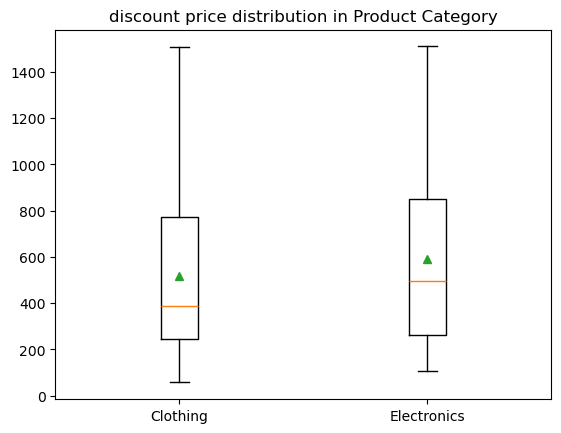

TtestResult(statistic=np.float64(-0.6739625241657531), pvalue=np.float64(0.5037079431376945), df=np.float64(46.0))

In [103]:
d=df.loc[df["Product Category"]=="Clothing","Discounted Price"]
f=df.loc[df["Product Category"]=="Electronics","Discounted Price"]
k=plt.boxplot([d,f],labels=["Clothing","Electronics"],showmeans=True)
plt.title("discount price distribution in Product Category")
plt.ylabel=("Discount Price")
plt.show()
stats.ttest_ind(d,f)

EDA

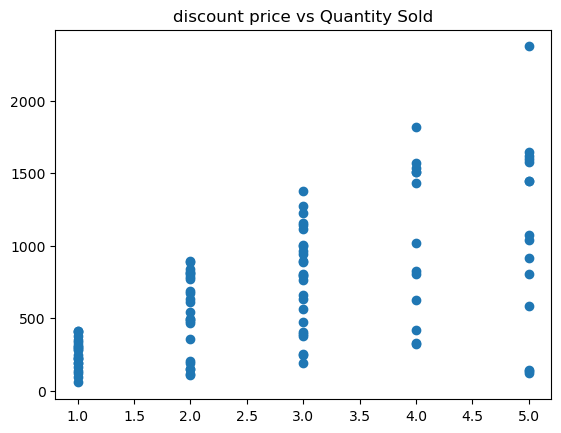

In [ ]:
x=df["Quantity Sold"]
y=df["Discounted Price"]
plt.scatter(x,y)
plt.title("discount price vs Quantity Sold")
plt.xlabel=("Quantity Sold")
plt.ylabel=("Discount Price")
plt.show()

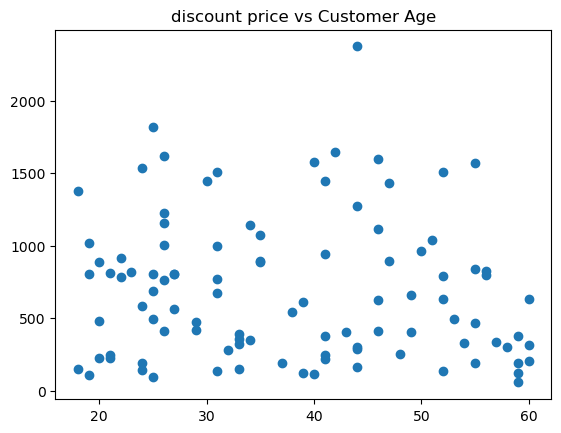

In [ ]:
x=df["Customer Age"]
y=df["Discounted Price"]
plt.scatter(x,y)
plt.title("discount price vs Customer Age")
plt.xlabel=("Customer Age")
plt.ylabel=("Discount Price")
plt.show()

Axes(0.125,0.11;0.62x0.77)


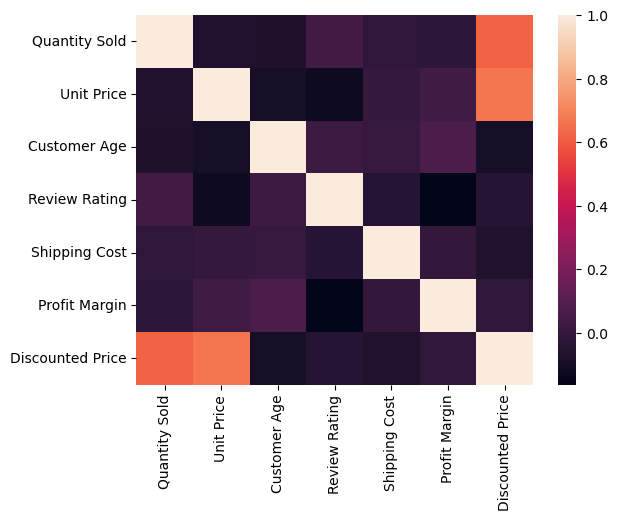

In [ ]:
a=df[["Quantity Sold", "Unit Price" , "Customer Age" ,"Review Rating" ,"Shipping Cost" ,"Profit Margin","Discounted Price"]].corr()
print(sns.heatmap(a))

In [ ]:
print(df["Product Category"].value_counts())
print(df["Product Name"].value_counts())

Product Category
Clothing          25
Electronics       23
Sports            21
Beauty            18
Home & Kitchen    13
Name: count, dtype: int64
Product Name
Smartphone      23
Yoga Mat        23
T-Shirt         20
Lipstick        18
Coffee Maker    16
Name: count, dtype: int64


C:\Users\bahug\AppData\Local\Temp\ipykernel_14184\1401805340.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  k=plt.boxplot([d,f,g,h,i],labels=["Clothing","Electronics","Sports","Beauty","Home & Kitchen"])


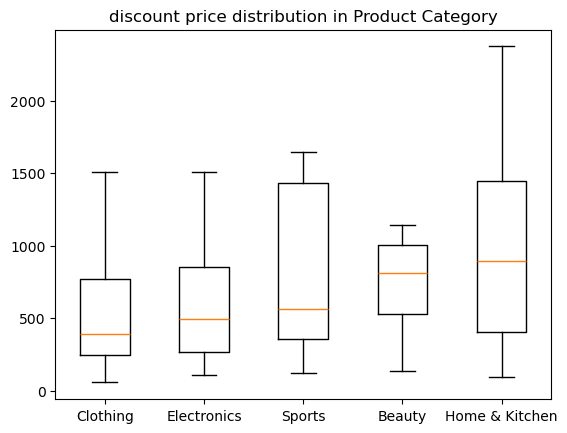

In [ ]:
d=df.loc[df["Product Category"]=="Clothing","Discounted Price"]
f=df.loc[df["Product Category"]=="Electronics","Discounted Price"]
g=df.loc[df["Product Category"]=="Sports","Discounted Price"]
h=df.loc[df["Product Category"]=="Beauty","Discounted Price"]
i=df.loc[df["Product Category"]=="Home & Kitchen","Discounted Price"]
k=plt.boxplot([d,f,g,h,i],labels=["Clothing","Electronics","Sports","Beauty","Home & Kitchen"])
plt.title("discount price distribution in Product Category")
plt.xlabel=("Product Category")
plt.ylabel=("Discount Price")
plt.show()

Date
1    23031.80
2    22475.11
3    23657.05
4     7767.32
Name: Total Sales, dtype: float64


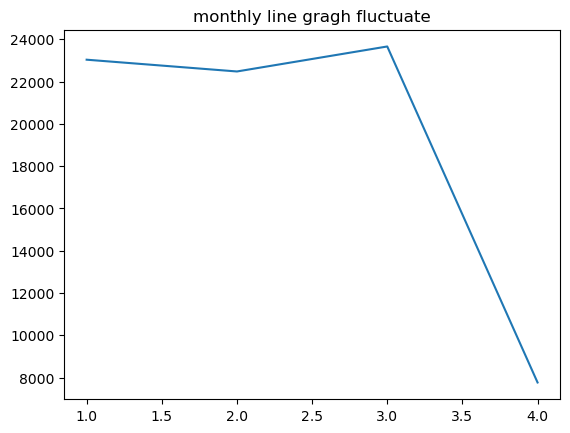

In [ ]:
Months=df.groupby(df["Date"].dt.month)["Total Sales"].sum()
print(Months)
plt.plot(Months)
plt.title("monthly line gragh fluctuate")
plt.show()


Product Category
Beauty            14609.57
Clothing          14132.65
Electronics       15271.19
Home & Kitchen    13858.38
Sports            19059.49
Name: Total Sales, dtype: float64


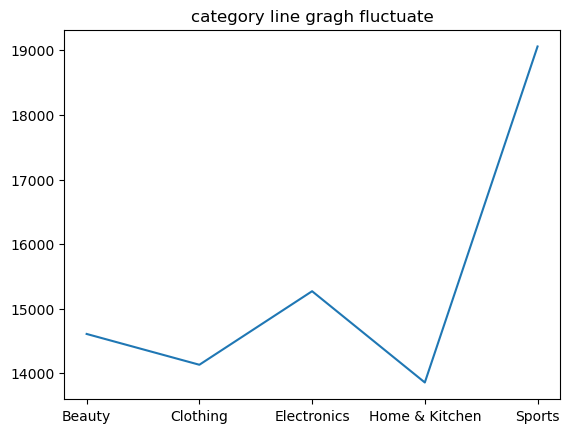

In [ ]:
category=df.groupby(df["Product Category"])["Total Sales"].sum()
print(category)
plt.plot(category)
plt.title("category line gragh fluctuate")
plt.show()


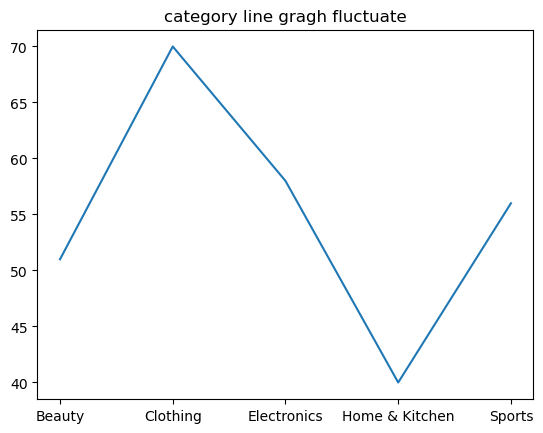

In [ ]:
category=df.groupby(df["Product Category"])["Quantity Sold"].sum()
plt.plot(category)
plt.title("category line gragh fluctuate")
plt.show()

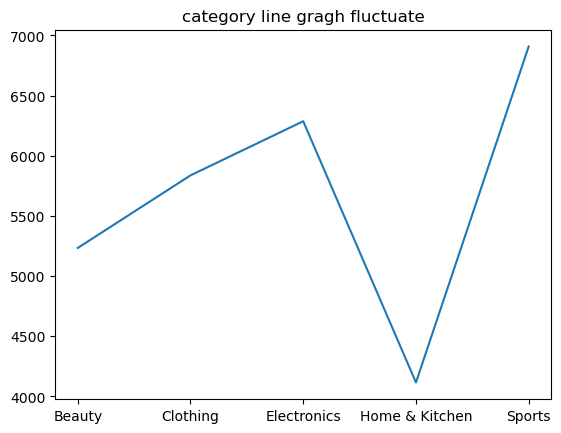

In [ ]:

category=df.groupby(df["Product Category"])["Unit Price"].sum()
plt.plot(category)
plt.title("category line gragh fluctuate")
plt.show()


FEATURE ENGINNERING

In [ ]:
t=pd.get_dummies(df[["Product Name","Product Category"]])
print(t.dtypes)
print(t.shape)

Product Name_Coffee Maker          bool
Product Name_Lipstick              bool
Product Name_Smartphone            bool
Product Name_T-Shirt               bool
Product Name_Yoga Mat              bool
Product Category_Beauty            bool
Product Category_Clothing          bool
Product Category_Electronics       bool
Product Category_Home & Kitchen    bool
Product Category_Sports            bool
dtype: object
(100, 10)


In [ ]:
j=pd.DataFrame(df[["Quantity Sold", "Unit Price" , "Customer Age" ,"Review Rating" ,"Shipping Cost" ,"Profit Margin"]])
x=pd.concat([j[["Quantity Sold", "Unit Price" , "Customer Age" ,"Review Rating" ,"Shipping Cost" ,"Profit Margin"]],t],axis=1)
print(h.isnull().sum())

y=df["Discounted Price"]
print(x.shape)
print(y.shape)


0
(100, 16)
(100,)


In [ ]:

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3, random_state=42)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(70, 16)
(30, 16)
(70,)
(30,)


In [ ]:
scaler = StandardScaler()
x_train_scaler=scaler.fit_transform(x_train)
x_test_scaler=scaler.transform(x_test)


In [ ]:
lr=LinearRegression()
lr.fit(x_train_scaler,y_train)
y_predict=lr.predict(x_test_scaler)


REGRESSION MODEL


In [ ]:
print("Mean Absolute Error lr : ")
print(mean_absolute_error(y_test,y_predict))
print("mean_squared_error : ")
print(mean_squared_error(y_test,y_predict))
print("root_mean_squared_error : ")
print(root_mean_squared_error(y_test,y_predict))
print("r2_score : ")
print(r2_score(y_test,y_predict))


Mean Absolute Error lr : 
162.42400332859663
mean_squared_error : 
44866.31082761785
root_mean_squared_error : 
211.8166915698993
r2_score : 
0.8388841530969882


In [ ]:
dt=DecisionTreeRegressor()
dt.fit(x_train_scaler,y_train)
y_predict_d=dt.predict(x_test_scaler)
print("Mean Absolute Error dt: ")
print(mean_absolute_error(y_test,y_predict_d))
print("mean_squared_error : ")
print(mean_squared_error(y_test,y_predict_d))
print("root_mean_squared_error : ")
print(root_mean_squared_error(y_test,y_predict_d))
print("r2_score : ")
print(r2_score(y_test,y_predict_d))



Mean Absolute Error dt: 
133.31900000000002
mean_squared_error : 
35168.91864999999
root_mean_squared_error : 
187.53378002375996
r2_score : 
0.8737076882757663


In [ ]:
rf=RandomForestRegressor()
rf.fit(x_train_scaler,y_train)
y_predict_r=rf.predict(x_test_scaler)
print("Mean Absolute Error rf : ")
print(mean_absolute_error(y_test,y_predict_r))
print("mean_squared_error : ")
print(mean_squared_error(y_test,y_predict_r))
print("root_mean_squared_error : ")
print(root_mean_squared_error(y_test,y_predict_r))
print("r2_score : ")
print(r2_score(y_test,y_predict_r))


Mean Absolute Error rf : 
109.9343833333334
mean_squared_error : 
35016.503133670994
root_mean_squared_error : 
187.12697062067508
r2_score : 
0.8742550155362772


In [ ]:
print("cross_val_score of lr :")
print(cross_val_score(lr ,x_train_scaler,y_train,cv=5))
print("cross_val_score of rf :")
print(cross_val_score(rf ,x_train_scaler,y_train,cv=5))
print("cross_val_score of dt :")
print(cross_val_score(dt ,x_train_scaler,y_train,cv=5))

cross_val_score of lr :
[0.85805488 0.89717997 0.88257768 0.77321634 0.8549576 ]
cross_val_score of rf :
[0.60915522 0.94177578 0.85818556 0.84511758 0.91846135]
cross_val_score of dt :
[0.59351534 0.9435388  0.85293467 0.63639167 0.83995183]


MODEL OPTIMIZATION

In [ ]:
#HYPERPARAMETER
c=RandomForestRegressor()
l=GridSearchCV(c ,param_grid={'n_estimators':[50,100,250],'max_depth':[5,10,15],'min_samples_split':[10,2,6]},cv=5,scoring='r2')
l.fit(x_train_scaler,y_train)
u=print(l.best_params_)
print(l.best_score_)


{'max_depth': 15, 'min_samples_split': 2, 'n_estimators': 250}
0.8587625705032002


In [ ]:
best_model=l.best_estimator_
y_predict_e=best_model.predict(x_test_scaler)
print("Mean Absolute Error  : ")
print(mean_absolute_error(y_test,y_predict_e))
print("mean_squared_error : ")
print(mean_squared_error(y_test,y_predict_e))
print("root_mean_squared_error : ")
print(root_mean_squared_error(y_test,y_predict_e))
print("r2_score : ")
print(r2_score(y_test,y_predict_e))
print("cross_val_score of best model :")
print(cross_val_score(best_model ,x_train_scaler,y_train,cv=5))


Mean Absolute Error  : 
104.9568653333335
mean_squared_error : 
33477.13120817445
root_mean_squared_error : 
182.96756873329886
r2_score : 
0.8797829318480953
cross_val_score of best model :
[0.65389996 0.92820519 0.8638182  0.85651931 0.91832276]


In [ ]:
compare = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest", "Tuned Random Forest"],
    "MAE": [
        mean_absolute_error(y_test, y_predict),
        mean_absolute_error(y_test, y_predict_d),
        mean_absolute_error(y_test, y_predict_r),
        mean_absolute_error(y_test, y_predict_e)
    ],
    "MSE": [
        mean_squared_error(y_test, y_predict),
        mean_squared_error(y_test, y_predict_d),
        mean_squared_error(y_test, y_predict_r),
        mean_squared_error(y_test, y_predict_e)
    ],
    "RMSE": [
        root_mean_squared_error(y_test, y_predict),
        root_mean_squared_error(y_test, y_predict_d),
        root_mean_squared_error(y_test, y_predict_r),
        root_mean_squared_error(y_test, y_predict_e)
    ],
    "R2": [
        r2_score(y_test, y_predict),
        r2_score(y_test, y_predict_d),
        r2_score(y_test, y_predict_r),
        r2_score(y_test, y_predict_e)
    ],
    "CV_R2": [
        cross_val_score(lr, x_train_scaler, y_train, cv=5).mean(),
        cross_val_score(dt, x_train_scaler, y_train, cv=5).mean(),
        cross_val_score(rf, x_train_scaler, y_train, cv=5).mean(),
        cross_val_score(best_model, x_train_scaler, y_train, cv=5).mean()
    ]
})

compare

,Model,MAE,MSE,RMSE,R2,CV_R2
0,Linear Regression,162.424003,44866.310828,211.816692,0.838884,0.853197
1,Decision Tree,133.319000,35168.918650,187.533780,0.873708,0.730184
2,Random Forest,109.934383,35016.503134,187.126971,0.874255,0.848687
3,Tuned Random Forest,104.956865,33477.131208,182.967569,0.879783,0.847599
